<a href="https://colab.research.google.com/github/AlejandroBlandonV/Rappi-Plus-Analisis/blob/main/S12_Estudiante_Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [ ]:
# importar librerías
import pandas as pd
import numpy as np

In [ ]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')


In [ ]:
# explorar datasets
# Explorando Orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [ ]:
orders.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [ ]:
#Explorando Catalog
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [ ]:
catalog.head(7)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [ ]:
#Explorando Marketing
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


In [ ]:
marketing.isna().mean()

fecha         0.000000
pais          0.000000
id_campaña    0.000000
canal         0.062346
gasto         0.000000
dtype: float64

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

**Limpiando Orders**

In [ ]:
#Convertir a Fecha
orders['fecha_hora_pedido']=pd.to_datetime(orders['fecha_hora_pedido'],errors='coerce')

In [ ]:
orders['fecha_hora_pedido'].dt.year.unique()

array([2025])

In [ ]:
columnas_categoricas_orders=['pais','dispositivo','fuente_referencia','nombre_producto','categoria_producto']

In [ ]:
for col in columnas_categoricas_orders:
    print(orders[col].unique())
    print()
    print(orders[col].value_counts())
    print()
    print(f"Nulos {col}: ",orders[col].isna().sum())
    print()

['Argentina' 'Mexico' 'Colombia' 'mexico' 'colombia' 'argentina' nan]

Colombia     7520
Mexico       7502
Argentina    7291
mexico        865
colombia      823
argentina     799
Name: pais, dtype: int64

Nulos pais:  300

['desktop' 'mobile' nan]

desktop    12759
mobile     12321
Name: dispositivo, dtype: int64

Nulos dispositivo:  20

['organic' 'paid_search' 'social' nan]

social         8428
organic        8329
paid_search    8313
Name: fuente_referencia, dtype: int64

Nulos fuente_referencia:  30

['Jacket-Winter-M' 'Tablet-Standard-64GB' 'Blender-XL-Red'
 'Laptop-Gaming-16GB' 'Sneakers-Urban-42' 'Phone-Pro-128GB'
 'Vacuum-Pro-Black' nan]

Vacuum-Pro-Black        4199
Blender-XL-Red          4195
Jacket-Winter-M         4192
Sneakers-Urban-42       4160
Laptop-Gaming-16GB      2794
Tablet-Standard-64GB    2780
Phone-Pro-128GB         2750
Name: nombre_producto, dtype: int64

Nulos nombre_producto:  30

['Moda' 'Electronica' 'Hogar' nan]

Hogar          8385
Moda           8323
El

In [ ]:
columnas_numericas_orders=['cantidad','precio_unitario','monto_descuento','monto_total']

In [ ]:
orders[columnas_numericas_orders].isna().sum()

cantidad           50
precio_unitario    50
monto_descuento    50
monto_total         0
dtype: int64

In [ ]:
# 1. Definir las columnas numéricas que quieres inspeccionar

# 2. Crear la máscara: busca NaN en esas columnas y con .any(axis=1)
# verifica si hay al menos uno por cada fila
mascara_nan = orders[columnas_numericas_orders].isna().any(axis=1)

# 3. Filtrar el DataFrame orders para ver las filas completas
filas_con_nan = orders[mascara_nan]

# Mostrar el resultado (puedes añadir .head() si son muchas)
print(filas_con_nan)

     id_pedido id_usuario fecha_hora_pedido       pais dispositivo  \
74    order_74  user_6172        2025-01-15  Argentina     desktop   
75    order_75  user_6588        2025-06-19   Colombia      mobile   
76    order_76  user_3193        2025-03-17  Argentina      mobile   
77    order_77   user_775        2025-06-24  Argentina     desktop   
78    order_78  user_2702        2025-03-19  Argentina     desktop   
79    order_79  user_6438        2025-03-22   Colombia     desktop   
80    order_80  user_6790        2025-01-03     Mexico     desktop   
81    order_81   user_232        2025-05-16     Mexico      mobile   
82    order_82  user_5665        2025-02-07   Colombia      mobile   
83    order_83  user_5225        2025-04-25  Argentina      mobile   
84    order_84  user_5599        2025-05-20   Colombia     desktop   
85    order_85  user_4051        2025-06-08  Argentina      mobile   
86    order_86  user_2260        2025-06-28  Argentina      mobile   
87    order_87    us

In [ ]:
orders['pais']=orders['pais'].replace({'argentina':'Argentina','mexico':'Mexico','colombia':'Colombia'})

In [ ]:
orders['pais'].unique()

array(['Argentina', 'Mexico', 'Colombia', nan], dtype=object)

In [ ]:
# Lista de columnas a revisar
columnas_con_nan = ['pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto','cantidad','precio_unitario','monto_descuento']

# Aplicar el cambio directamente en 'orders'
orders.dropna(subset=columnas_con_nan, inplace=True)

In [ ]:
orders['pais'].unique()

array(['Argentina', 'Mexico', 'Colombia'], dtype=object)

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24700 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24700 non-null  object        
 1   id_usuario          24700 non-null  object        
 2   fecha_hora_pedido   24700 non-null  datetime64[ns]
 3   pais                24700 non-null  object        
 4   dispositivo         24700 non-null  object        
 5   fuente_referencia   24700 non-null  object        
 6   nombre_producto     24700 non-null  object        
 7   categoria_producto  24700 non-null  object        
 8   cantidad            24700 non-null  float64       
 9   precio_unitario     24700 non-null  float64       
 10  monto_descuento     24700 non-null  float64       
 11  monto_total         24700 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.4+ MB


In [ ]:
orders['id_pedido'].duplicated().sum()

100

In [ ]:

# Al usar keep=False, TODAS las ocurrencias de un ID duplicado se marcan como True
mascara_todos_duplicados = orders['id_pedido'].duplicated(keep=False)

# Filtramos y ordenamos por 'id_pedido' para que queden juntas y sea fácil compararlas
analisis_duplicados = orders[mascara_todos_duplicados].sort_values(by='id_pedido')

# Mostrar el resultado
print(analisis_duplicados)


         id_pedido id_usuario fecha_hora_pedido       pais dispositivo  \
25023  order_10082   user_690        2025-02-17  Argentina     desktop   
10082  order_10082   user_690        2025-02-17  Argentina     desktop   
25037  order_10709  user_6783        2025-02-16   Colombia      mobile   
10709  order_10709  user_6783        2025-02-16   Colombia      mobile   
25065  order_10829  user_7697        2025-01-23  Argentina      mobile   
...            ...        ...               ...        ...         ...   
25048   order_8326  user_6177        2025-06-14  Argentina      mobile   
25043   order_8414  user_4073        2025-05-10   Colombia      mobile   
8414    order_8414  user_4073        2025-05-10   Colombia      mobile   
25056    order_974  user_3262        2025-05-04  Argentina     desktop   
974      order_974  user_3262        2025-05-04  Argentina     desktop   

      fuente_referencia    nombre_producto categoria_producto  cantidad  \
25023            social  Sneakers-Ur

In [ ]:
orders.drop_duplicates(subset='id_pedido',inplace=True)

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24600 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24600 non-null  object        
 1   id_usuario          24600 non-null  object        
 2   fecha_hora_pedido   24600 non-null  datetime64[ns]
 3   pais                24600 non-null  object        
 4   dispositivo         24600 non-null  object        
 5   fuente_referencia   24600 non-null  object        
 6   nombre_producto     24600 non-null  object        
 7   categoria_producto  24600 non-null  object        
 8   cantidad            24600 non-null  float64       
 9   precio_unitario     24600 non-null  float64       
 10  monto_descuento     24600 non-null  float64       
 11  monto_total         24600 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.4+ MB


In [ ]:
orders[columnas_numericas_orders].describe()

,cantidad,precio_unitario,monto_descuento,monto_total
count,24600.000000,24600.000000,24600.000000,2.460000e+04
mean,7.195650,259.388964,4.502846,2.107170e+03
std,298.973686,138.686403,5.225201,9.995022e+04
min,1.000000,20.030000,0.000000,5.240000e+00
25%,1.000000,138.752500,0.000000,1.806375e+02
50%,2.000000,258.785000,0.000000,3.417100e+02
75%,2.000000,380.372500,10.000000,5.193425e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


---

**Limpiando Marketing**

In [ ]:
# Convertimos a formato Fecha
marketing['fecha']=pd.to_datetime(marketing['fecha'],errors='coerce')

In [ ]:
marketing['fecha'].dt.year.unique()

array([2025])

Se toma la decisión de eliminar los nulos para no tener en una tabla de dimensiones valores nan


In [ ]:
marketing.dropna(subset=['canal'], inplace=True)

In [ ]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1519 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1519 non-null   datetime64[ns]
 1   pais        1519 non-null   object        
 2   id_campaña  1519 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1519 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 71.2+ KB


In [ ]:
columnas_categoricas_marketing=['pais','canal']

In [ ]:
for col in columnas_categoricas_marketing:
    print(marketing[col].unique())
    print()
    print(marketing[col].value_counts())
    print()

['Mexico' 'Colombia' 'Argentina']

Colombia     507
Mexico       506
Argentina    506
Name: pais, dtype: int64

['organic' 'paid_search' 'social']

paid_search    507
organic        506
social         506
Name: canal, dtype: int64



In [ ]:
#Verificar que no existan duplicados
marketing.duplicated().sum()

0

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

In [ ]:
#Verificamos Llaves para hacer inner merge
orders['nombre_producto'].unique()

array(['Jacket-Winter-M', 'Tablet-Standard-64GB', 'Blender-XL-Red',
       'Laptop-Gaming-16GB', 'Sneakers-Urban-42', 'Phone-Pro-128GB',
       'Vacuum-Pro-Black'], dtype=object)

In [ ]:
catalog['nombre_producto'].unique()

array(['Laptop-Gaming-16GB', 'Phone-Pro-128GB', 'Tablet-Standard-64GB',
       'Blender-XL-Red', 'Vacuum-Pro-Black', 'Sneakers-Urban-42',
       'Jacket-Winter-M'], dtype=object)

In [ ]:
orders['categoria_producto'].unique()

array(['Moda', 'Electronica', 'Hogar'], dtype=object)

In [ ]:
orders['categoria_producto']=orders['categoria_producto'].replace('Electronica','Electrónica')

In [ ]:
orders['categoria_producto'].unique()

array(['Moda', 'Electrónica', 'Hogar'], dtype=object)

In [ ]:
catalog['categoria_producto'].unique()

array(['Electrónica', 'Hogar', 'Moda'], dtype=object)

In [ ]:
merged_inner=pd.merge(orders,catalog,on=['nombre_producto','categoria_producto'],how='inner')

In [ ]:
merged_inner.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24600 entries, 0 to 24599
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24600 non-null  object        
 1   id_usuario          24600 non-null  object        
 2   fecha_hora_pedido   24600 non-null  datetime64[ns]
 3   pais                24600 non-null  object        
 4   dispositivo         24600 non-null  object        
 5   fuente_referencia   24600 non-null  object        
 6   nombre_producto     24600 non-null  object        
 7   categoria_producto  24600 non-null  object        
 8   cantidad            24600 non-null  float64       
 9   precio_unitario     24600 non-null  float64       
 10  monto_descuento     24600 non-null  float64       
 11  monto_total         24600 non-null  float64       
 12  costo_unitario      24600 non-null  float64       
 13  proveedor           24600 non-null  object    

In [ ]:
#KPIs Rentabilidad
ingreso_total=merged_inner['monto_total'].sum()
print(f"Ingreso Total: {ingreso_total}")

costo_total=(merged_inner['costo_unitario']*merged_inner['cantidad']).sum()
print(f"Costo Total: {costo_total:.2f}")

invertido_marketing=marketing['gasto'].sum()
print(f"Invertido en Marketing: {invertido_marketing:.2f}")

profit=ingreso_total-costo_total-invertido_marketing
print(f"Profit: {profit:.2f}")
print(f"Rentabilidad:{(profit/ingreso_total)*100:.2f}%")

Ingreso Total: 51836375.14
Costo Total: 43078678.80
Invertido en Marketing: 2694664.43
Profit: 6063031.91
Rentabilidad:11.70%


In [ ]:
#Comportamiento de Ventas
ticket_promedio=merged_inner['monto_total'].mean()
print(f"Ticket Promedio: {ticket_promedio:.2f}")

cantidad_promedio=merged_inner['cantidad'].mean()
print(f"Cantidad Promedio de Productos por Orden: {cantidad_promedio:.2f}")

producto_top=merged_inner.groupby('nombre_producto')['cantidad'].sum()
print(f"Producto mas vendido: {producto_top}")

marketing_por_canal=marketing.groupby('canal')['gasto'].sum()
print(f"Invertido por Canal: {marketing_por_canal}")

Ticket Promedio: 2107.17
Cantidad Promedio de Productos por Orden: 7.20
Producto mas vendido: nombre_producto
Blender-XL-Red            6184.0
Jacket-Winter-M           6185.0
Laptop-Gaming-16GB      144160.0
Phone-Pro-128GB           4088.0
Sneakers-Urban-42         6085.0
Tablet-Standard-64GB      4108.0
Vacuum-Pro-Black          6203.0
Name: cantidad, dtype: float64
Invertido por Canal: canal
organic        913533.01
paid_search    863088.21
social         918043.21
Name: gasto, dtype: float64


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos,
    CASE nombre_evento
        WHEN 'first_visit' THEN 1
        WHEN 'select_item' THEN 2
        WHEN 'add_to_cart' THEN 3
        WHEN 'begin_checkout' THEN 4
        WHEN 'add_payment_info' THEN 5
        WHEN 'purchase' THEN 6
    END AS orden_paso
FROM events
WHERE nombre_evento IN ('first_visit', 'select_item', 'add_to_cart', 'begin_checkout', 'add_payment_info','purchase')
GROUP BY nombre_evento
ORDER BY orden_paso;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos,orden_paso
0,first_visit,7796,1
1,select_item,7582,2
2,add_to_cart,7634,3
3,begin_checkout,7208,4
4,add_payment_info,6250,5
5,purchase,6240,6


In [ ]:
# PARTE 2: Conversiones (Corregido)
# ======================

query_conversion = '''
WITH funnel_steps AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos,
        CASE nombre_evento
            WHEN 'first_visit' THEN 1
            WHEN 'select_item' THEN 2
            WHEN 'add_to_cart' THEN 3
            WHEN 'begin_checkout' THEN 4
            WHEN 'add_payment_info' THEN 5
            WHEN 'purchase' THEN 6
        END AS orden_paso
    FROM events
    WHERE nombre_evento IN ('first_visit', 'select_item', 'add_to_cart', 'begin_checkout', 'add_payment_info', 'purchase')
    GROUP BY nombre_evento
),
funnel_calculations AS (
    SELECT
        orden_paso,
        nombre_evento,
        usuarios_unicos,
        LAG(usuarios_unicos, 1) OVER (ORDER BY orden_paso) AS usuarios_paso_anterior,
        FIRST_VALUE(usuarios_unicos) OVER (ORDER BY orden_paso) AS usuarios_iniciales
    FROM funnel_steps
)
SELECT
    orden_paso,
    nombre_evento,
    usuarios_unicos,

    -- Cambiado a * 100 en lugar de usar texto, el formato porcentaje se lo das en Pandas o dejas el número limpio
    CASE
        WHEN orden_paso = 1 THEN 100.0
        ELSE ROUND((usuarios_unicos::NUMERIC / usuarios_paso_anterior) * 100, 2)
    END AS tasa_conversion_paso_a_paso,

    CASE
        WHEN orden_paso = 1 THEN 0.0
        ELSE ROUND((1 - (usuarios_unicos::NUMERIC / usuarios_paso_anterior)) * 100, 2)
    END AS tasa_perdida_paso,

    ROUND((usuarios_unicos::NUMERIC / usuarios_iniciales) * 100, 2) AS tasa_conversion_final
FROM funnel_calculations
ORDER BY orden_paso;
'''

# Ejecutamos ahora sin problemas de parámetros
conversion = pd.read_sql(query_conversion, con=engine)
conversion

,orden_paso,nombre_evento,usuarios_unicos,tasa_conversion_paso_a_paso,tasa_perdida_paso,tasa_conversion_final
0,1,first_visit,7796,100.00,0.00,100.00
1,2,select_item,7582,97.26,2.74,97.26
2,3,add_to_cart,7634,100.69,-0.69,97.92
3,4,begin_checkout,7208,94.42,5.58,92.46
4,5,add_payment_info,6250,86.71,13.29,80.17
5,6,purchase,6240,99.84,0.16,80.04


---

## 🔹Análisis Funnel
**Respuestas**

-Se observan la cantidad de eventos por los que debe pasar el usuario para realizar una compra, desde su Primera Visita hasta la Compra del producto.
- Se logra identificar el Mayor Drop-Off entre begin_checkout y add-payment_info en la que casi 1000 usuarios se pierden, es decir un 13.29 %.
- Se observa una anomalía entre los eventos select_item y add_to_cart, en lugar de una caída en la cantidad de clientes, hay un aumento, quiere decir que posiblemente el usuario ya sabe que producto comprar y no lo selecciona, sino que de una vez lo envía al carrito.
- Analizando las tasas de conversion del funnel en cada paso, se puede decir que son relativamente buenas, hay una tasa de conversión final del 80.04%, esto posiblemente sucede por que la página es fácil de llevar para el usuario, va directo al grano. Sin embargo, como se menciona antes, el mayor drop-off es en add_payment_info, se debe hacer una revisión aquí, y preguntarse: es muy complejo añadir la información del medio de pago? Cómo podemos optmizar esta parte?, o el usuario se pierde porque son muchos datos que hay que llenar?


## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohortes_iniciales AS (
    -- 1. Definimos el mes de la cohorte y contamos los usuarios iniciales
    SELECT
        -- Usamos DATE_TRUNC para agrupar por mes, asegurando el formato DATE
        DATE_TRUNC('month', CAST(fecha_registro AS DATE)) AS cohorte_mes,
        COUNT(DISTINCT id_usuario) AS usuarios_iniciales
    FROM users
    GROUP BY 1
),
actividad_semanal AS (
    -- 2. Identificamos en qué semanas estuvo activo cada usuario real de forma única
    SELECT
        u.id_usuario,
        DATE_TRUNC('month', CAST(u.fecha_registro AS DATE)) AS cohorte_mes,
        -- Evaluamos si el usuario registra actividad (activo = 1) en los rangos de días de cada semana
        MAX(CASE WHEN ua.dias_despues_registro BETWEEN 1 AND 7 AND ua.activo = 1 THEN 1 ELSE 0 END) AS activo_w1,
        MAX(CASE WHEN ua.dias_despues_registro BETWEEN 8 AND 14 AND ua.activo = 1 THEN 1 ELSE 0 END) AS activo_w2,
        MAX(CASE WHEN ua.dias_despues_registro BETWEEN 15 AND 21 AND ua.activo = 1 THEN 1 ELSE 0 END) AS activo_w3
    FROM users u
    LEFT JOIN user_activity ua ON u.id_usuario = ua.id_usuario
    GROUP BY u.id_usuario, u.fecha_registro
),
conteo_retenidos AS (
    -- 3. Sumamos cuántos usuarios únicos se mantuvieron activos por cohorte
    SELECT
        cohorte_mes,
        SUM(activo_w1) AS retenido_w1,
        SUM(activo_w2) AS retenido_w2,
        SUM(activo_w3) AS retenido_w3
    FROM actividad_semanal
    GROUP BY cohorte_mes
)
-- 4. Unimos todo y calculamos los porcentajes finales de retención
SELECT
    TO_CHAR(c.cohorte_mes, 'YYYY-MM') AS cohorte, -- Formato limpio para leer el mes (Ej: 2025-01)
    c.usuarios_iniciales,

    -- Totales absolutos
    r.retenido_w1,
    r.retenido_w2,
    r.retenido_w3,

    -- Porcentajes de retención (con %% escapado para Pandas)
    ROUND((r.retenido_w1::NUMERIC / c.usuarios_iniciales) * 100, 2) AS semana_1_porcentaje,
    ROUND((r.retenido_w2::NUMERIC / c.usuarios_iniciales) * 100, 2) AS semana_2_porcentaje,
    ROUND((r.retenido_w3::NUMERIC / c.usuarios_iniciales) * 100, 2) AS semana_3_porcentaje
FROM cohortes_iniciales c
JOIN conteo_retenidos r ON c.cohorte_mes = r.cohorte_mes
ORDER BY c.cohorte_mes;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1_porcentaje,semana_2_porcentaje,semana_3_porcentaje
0,2025-01,1627,697,668,656,42.84,41.06,40.32
1,2025-02,1444,611,609,635,42.31,42.17,43.98
2,2025-03,1636,677,705,690,41.38,43.09,42.18
3,2025-04,1606,680,697,663,42.34,43.40,41.28
4,2025-05,1687,695,676,706,41.20,40.07,41.85


---

## 🔹Análisis Cohortes
**Respuestas**

-Se dividen en 5 cohortes desde enero de 2025 hasta mayo de 2025.

- La cohorte con más cantidad de usuarios fue la de Mayo con 1687 mientras que la peor fue la de febrero con 1444.
- Lo importante no es solo cuantos usarios haya al principio de cada cohorte sino qué tanto se retienen durante esas 3 semanas.
- En la semana 1 la cohorte con mejor retención fue la de enero con 42.84%
- En la semana 2 se observa un aumento en 2 cohortes respecto a la semana 1, esto quiere decir, que hubo usuarios inactivos en la semana 1 pero apenas se activaron en la semana dos. Las Cohortes fueron las de marzo y abril, que pasaron de 41.38% a 43.09% y 42.34% a 43.40 respectivamente.
- Finalmente se observa que en la semana 3 la cohorte con mejor retención fue la de Febrero con casi un 44% de retención, siendo la cohorte con menor cantidad de usuarios de todas.


## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
from scipy.stats import levene, ttest_ind
from statsmodels.stats.proportion import proportions_ztest


In [ ]:
#Cargar el archivo
experiment=pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

In [ ]:
experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [ ]:
#Verificar clientes únicos
experiment['id_usuario'].duplicated().sum()

0

In [ ]:
#Verificar si hay nulos
experiment.isna().sum()

id_usuario         0
variante           0
convirtio          0
dispositivo        0
pais               0
duracion_sesion    0
timestamp          0
dtype: int64

In [ ]:
#Cambiar a formato fecha
experiment['timestamp']=pd.to_datetime(experiment['timestamp'],errors='coerce')

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", experiment["timestamp"].min())
print("Fecha máxima:", experiment["timestamp"].max())

Fecha mínima: 2025-01-01 00:00:00
Fecha máxima: 2025-06-30 00:00:00


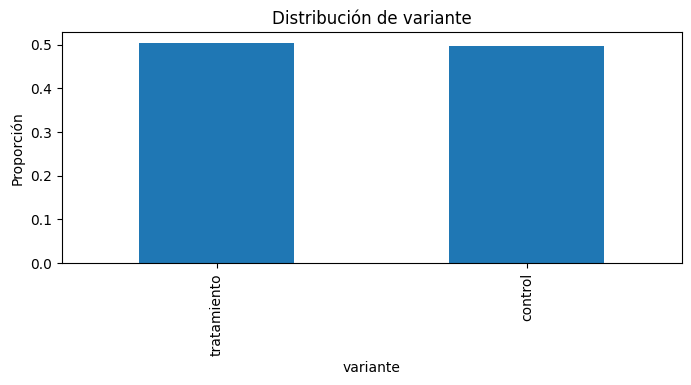

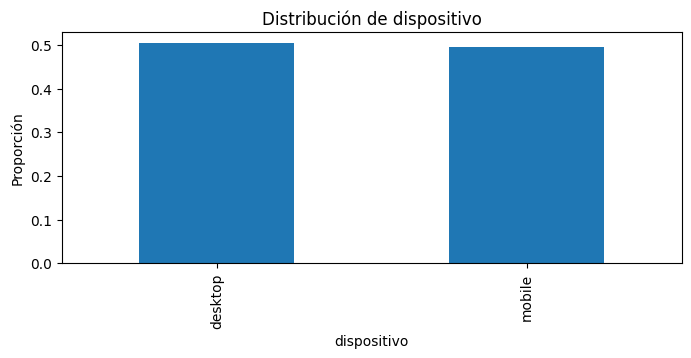

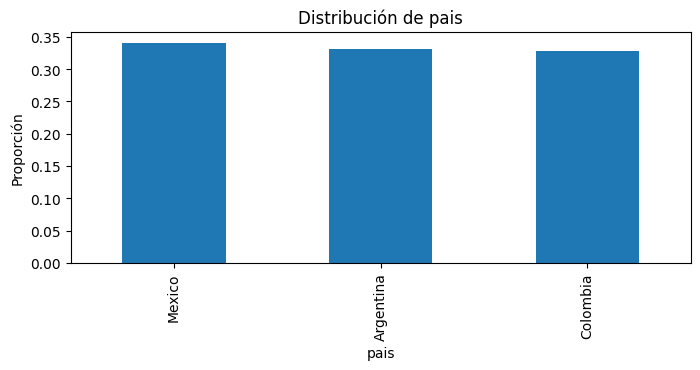

In [ ]:
#Distribución de Columnas Categóricas
col_categoricas_exp=['variante','dispositivo','pais']

for col in col_categoricas_exp:
    proporciones=experiment[col].value_counts(normalize=True)
    plt.figure(figsize=(8,3))
    proporciones.plot(kind='bar')
    plt.title(f'Distribución de {col}')
    plt.ylabel('Proporción')
    plt.xlabel(col)
    plt.show()

In [ ]:
#Creamos un dataset de usuarios que sí convirtieron
experiment_converted=experiment[experiment['convirtio']==1]

In [ ]:
#Info del convertidos
experiment_converted.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1599 entries, 2 to 9991
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_usuario       1599 non-null   object        
 1   variante         1599 non-null   object        
 2   convirtio        1599 non-null   int64         
 3   dispositivo      1599 non-null   object        
 4   pais             1599 non-null   object        
 5   duracion_sesion  1599 non-null   float64       
 6   timestamp        1599 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 99.9+ KB


In [ ]:
#Info estadistica convertidos
experiment_converted.describe()

,convirtio,duracion_sesion
count,1599.0,1599.000000
mean,1.0,160.180256
std,0.0,82.445774
min,1.0,20.350000
25%,1.0,85.440000
50%,1.0,160.230000
75%,1.0,231.995000
max,1.0,299.590000


**Resumen estadístico de usuarios que convierten**  
- En promedio los usuarios que convierten permanecen en sesión alrededor de 160 segundos em promedio, con un mínimo de 20 segundos y un máximo de 299 segundos. Cabe resaltar que de los 10 mil usuarios solo 1599 convierten, eso es apenas un 15.99%

In [ ]:
# Tiempo del usuario por variante
tratamiento = experiment_converted[experiment_converted['variante']=='tratamiento']['duracion_sesion']
control = experiment_converted[experiment_converted['variante']=='control']['duracion_sesion']

# Verificar cantidad de datos que tiene cada grupo
len(tratamiento), len(control)

(820, 779)

### Prueba Varianzas

**Hipótesis:**
- **Hipótesis nula (H₀):** Varianzas de grupos iguales
- **Hipótesis alternativa (H₁):** Varianzas de grupos diferentes

In [ ]:
# Aplicar prueba Levene
l_stat,p_value_var=levene(tratamiento,control)

# Visualizar resultados
print(f"Estadístico de Levene : {l_stat}")
print(f"Valor p: {p_value_var}")
alpha=0.05
if p_value_var < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True).")


Estadístico de Levene : 0.23541038279679855
Valor p: 0.6276073584423275
No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True).


### Prueba T-student

**Hipótesis:**
- **Hipótesis nula (H₀):** El Tiempo en sesión es igual en tratamiento y control
- **Hipótesis alternativa (H₁):** El Tiempo en sesión es diferente en tratamiento y control

In [ ]:
### Prueba T student
ttest_ind(tratamiento,control,equal_var=True)
t_stat,p_value=ttest_ind(tratamiento,control,equal_var=True)

# Visualizar resultados
print(f"Estadístico t : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico t : -1.0596284409665528
Valor p: 0.28947390328346456


In [ ]:
alpha=0.05
if p_value < alpha:
    print('Rechazamos Ho, El Tiempo en sesión es diferente en tratamiento y control')
else:
    print('No Rechazamos Ho, No hay evidencia estadística de que el Tiempo en sesión es diferente en tratamiento y control')

No Rechazamos Ho, No hay evidencia estadística de que el Tiempo en sesión es diferente en tratamiento y control


In [ ]:
# Calcular promedios
media_tratamiento = tratamiento.mean()
media_control = control.mean()

print('La media para tratamiento es: ', media_tratamiento)
print('La media para control es: ', media_control)
print('La diferencia es de: ', media_tratamiento - media_control)

La media para tratamiento es:  158.0509268292683
La media para control es:  162.42165596919128
La diferencia es de:  -4.370729139922986


### 📝 Conclusión e interpretación

**Decisión:**  

No rechazamos la hipótesis nula,lo que significa que no hay diferencia estadísticamente significativa en el tiempo de sesión entre tratamiento y control.

**Interpretación de negocio:**  
Con base en una prueba t, no hay evidencia estadísitca de que exista una diferencia en el tiempo de sesión entre tratamiento y control.
En promedio, los usuarios que convirtieron en de control se mantuvieron más tiempo en sesión que los que convirtieron en tratamiento.
Este resultado se basa en una muestra de usuarios que realizaron una compra y no evalúa si la diferencia observada es suficiente para justificar un cambio desde una perspectiva de negocio.


### Prueba z para proporciones

**Hipótesis:**
- **Hipótesis nula (H₀):** La Tasa de conversión es igual en ambos grupos
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre ambos grupos

In [ ]:
# Número de usuarios convertidos por variante
conversiones=experiment.groupby('variante')['convirtio'].sum()
totales=experiment.groupby('variante')['convirtio'].count()

#Total de Usuarios por variante
exitos=[conversiones['tratamiento'],conversiones['control']]
observaciones=[totales['tratamiento'],totales['control']]

print("Usuarios convertidos por variante:\n", conversiones)
print("\nTotal de usuarios por variante:\n", totales)


Usuarios convertidos por variante:
 variante
control        779
tratamiento    820
Name: convirtio, dtype: int64

Total de usuarios por variante:
 variante
control        4965
tratamiento    5035
Name: convirtio, dtype: int64


In [ ]:
#Tasa de éxito
converted_rate_tratamiento=exitos[0]/observaciones[0]
converted_rate_control=exitos[1]/observaciones[1]

print(f"Tasa de éxito para tratamiento: {converted_rate_tratamiento}")
print()
print(f"Tasa de éxito para control: {converted_rate_control} ")

if converted_rate_tratamiento>converted_rate_control:
    print("Los Usuarios de tratamiento tiene mejor tasa de conversión que los usuarios de control")
else:
    print("Los Usuarios de control tiene mejor tasa de conversión que los usuarios de tratamiento")

print(f"La diferencia porcentual es de: {abs(converted_rate_tratamiento-converted_rate_control)}")


Tasa de éxito para tratamiento: 0.1628599801390268

Tasa de éxito para control: 0.1568982880161128 
Los Usuarios de tratamiento tiene mejor tasa de conversión que los usuarios de control
La diferencia porcentual es de: 0.005961692122914003


In [ ]:
# Aplicar prueba
proportions_ztest(exitos,observaciones)
z_stat,p_value_z,=proportions_ztest(exitos,observaciones)


# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value_z}")

Estadístico : 0.8132782986429474
Valor p: 0.41605851639119995


In [ ]:
if p_value_z<alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la Hipótesis Nula,  no hay evidencia estadística de una diferencia entre ambas páginas.

**Interpretación de negocio:**  
Con base en en una prueba z para proporciones, encontramos que no existe evidencia estadística de una diferencia en la tasa de conversión entre los usuarios de tratamiento y control.

En particular, los usuarios de tratamiento muestra una tasa de conversión mayor que los usuarios de control, por una diferencia de 0.596%

Este resultado se basa en una muestra de usuarios y no evalúa si la magnitud de la diferencia es suficiente para justificar una decisión de negocio.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

# Link Tablero Power BI
https://drive.google.com/file/d/1LDhHfw-YCNLJBeb6EIj3gRmwAd7L3fIi/view?usp=sharing